In [1]:
# Per-prompt global trie. Every rollout opens with a shared "<think>" token, so the root
# (empty prefix) and its "<think>" child carry identical stats. We feed several batches for ONE
# prompt and read the EMA per-prompt baseline off the ROOT after each batch. Because it is EMA
# (decay 0.9), the baseline tracks the improving policy rather than the all-history mean.
import numpy as np
from src.tree_trainer import PrefixTrie

prompt_trie = PrefixTrie()
EMA = 0.9
rewards = [
    [0.0, 0.0, 1.0, 0.0],   # batch 1: 1/4 correct
    [0.0, 1.0, 1.0, 0.0],   # batch 2: 2/4
    [1.0, 1.0, 1.0, 0.0],   # batch 3: 3/4
]

print(f"{'after':<9}{'n':>4}{'ema_mean':>10}{'ema_std':>9}{'batch_acc':>11}")
for b, seq_adv in enumerate(rewards, 1):
    for j, c in enumerate(seq_adv):
        prompt_trie.insert(["<think>", f"b{b}", f"r{j}"], adv=c,
                           rewards={"correctness_reward": c}, reward_ema=EMA)
    root = prompt_trie
    print(f"batch {b:<3}{root.count:>4}"
          f"{root.reward_mean('correctness_reward'):>10.3f}"
          f"{root.reward_std('correctness_reward'):>9.3f}"
          f"{np.mean(seq_adv):>11.2f}")

# root (empty prefix) == "</think>" child, since every rollout passes through both:
think = prompt_trie.get_node(["<think>"])              # built-in PrefixTrie method
print("\nroot vs <think>:  "
      f"count {root.count}=={think.count}  "
      f"mean {root.reward_mean('correctness_reward'):.3f}=={think.reward_mean('correctness_reward'):.3f}")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

objc[40659]: Class AVFFrameReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2e8250798) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x2fe9243a8). One of the two will be used. Which one is undefined.
objc[40659]: Class AVFAudioReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2e82507e8) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x2fe9243f8). One of the two will be used. Which one is undefined.


after       n  ema_mean  ema_std  batch_acc
batch 1     4     0.090    0.286       0.25
batch 2     8     0.230    0.421       0.50
batch 3    12     0.395    0.489       0.75

root vs <think>:  count 12==12  mean 0.395==0.395


In [2]:
node = prompt_trie.get_node(["<think>", "b1"]) 

# each trie carries a 'token', a walk along the tree (from root to the current node) gives the prefix
node.token
node.prefix()
prompt_trie.token

# Request: whilst I get it that for storage purpose one node gets one token is suitable as there might be 
#          other rollouts inserted which shares a different length prefix with current rollouts
#          But 'visualization' (and sampling!) should be done on a compresed trie (if a node got only one child node, 
#          it should be combined with its child node, so now it has one mode token on its node.token) 
#          I will require minimal code change here

# insert to PrefixTrie: toks (list of string, each specifying one node), 
prompt_trie.insert(toks = ["<wait>", "I", "know", "now"], adv=0.5, rewards={"correctness_reward": 1.0}, reward_ema=0.9)

# EMA reward mean / std, as well as maximal reward for a node
node = prompt_trie.get_node(["<think>"]) 
node.reward_mean('correctness_reward')
node.reward_std('correctness_reward')
node.best_reward('correctness_reward')

1.0

In [3]:
# ============================================================
# Idea 1. Buffered mean / std reward for advantage calculation
# ============================================================

key = "correctness_reward"
eps = 1e-8
trie = prompt_trie
base_m, base_s = trie.reward_mean(key), trie.reward_std(key)

corr = np.array(rewards[0])
adv_trie  = (corr - base_m)   / (base_s + eps)             # trie EMA baseline (cross-batch)
adv_batch = (corr - corr.mean()) / (corr.std() + eps)      # vanilla in-batch GRPO

In [4]:
# ========================================================================================================
# Idea 2. Buffered prefix resampling, replace 'all correct group' with resampled group from rare prefixes
# ========================================================================================================
# Requires: complementary "resampling group from prefix" + "special completion mask" (do NOT mask prefix response)
#           in case it led to format hacking (for 4B this might not be an issue) we can slot in good rollout to avoid it

key = "correctness_reward"

# this is still more efficient than calling .prefix from each node I agree
def iter_nodes(root):
    """Yield (prefix_tokens, node) for every node below `root` (DFS)."""
    stack = [([], root)]
    while stack:
        prefix, node = stack.pop()
        for tok, child in node.children.items():
            p = prefix + [tok]
            yield p, child
            stack.append((p, child))


# Good definition of score, aligned with my intuition (:>) | but we are not picking the "under-explored" node with this score
def prefix_score(node):
    # achievable (best>0)  x  rarity-of-success (1 - EMA mean)  /  exploration (count)
    return node.best_reward(key) * (1.0 - node.reward_mean(key)) / node.count


cands = [(p, n) for p, n in iter_nodes(trie) if n.best_reward(key) > 0]
cands.sort(key=lambda pn: prefix_score(pn[1]), reverse=True)  # high score = under-explored + rare win

print(f"{'prefix':<16}{'count':>6}{'max':>6}{'mean':>8}{'score':>8}")
for p, n in cands:
    print(f"{' '.join(p):<16}{n.count:>6}{n.best_reward(key):>6.2f}"
          f"{n.reward_mean(key):>8.3f}{prefix_score(n):>8.3f}")
    
# Requirement: 
# Visualization of the trie, with "score" and "rank" of our under-explored logics applied to each node

# Read-out: prefixes whose success is reachable but not yet reliable (mean < 1) and lightly
# explored bubble to the top; fully-solved leaves (mean = 1 -> rarity 0) sink to score 0.

prefix           count   max    mean   score
<think> b1           4  1.00   0.090   0.228
<think> b2           4  1.00   0.171   0.207
<think>             12  1.00   0.395   0.050
<think> b3           4  1.00   0.900   0.025
<wait>               1  1.00   1.000   0.000
<wait> I             1  1.00   1.000   0.000
<wait> I know        1  1.00   1.000   0.000
<wait> I know now     1  1.00   1.000   0.000
<think> b3 r0        1  1.00   1.000   0.000
<think> b3 r1        1  1.00   1.000   0.000
<think> b3 r2        1  1.00   1.000   0.000
<think> b2 r1        1  1.00   1.000   0.000
<think> b2 r2        1  1.00   1.000   0.000
<think> b1 r2        1  1.00   1.000   0.000


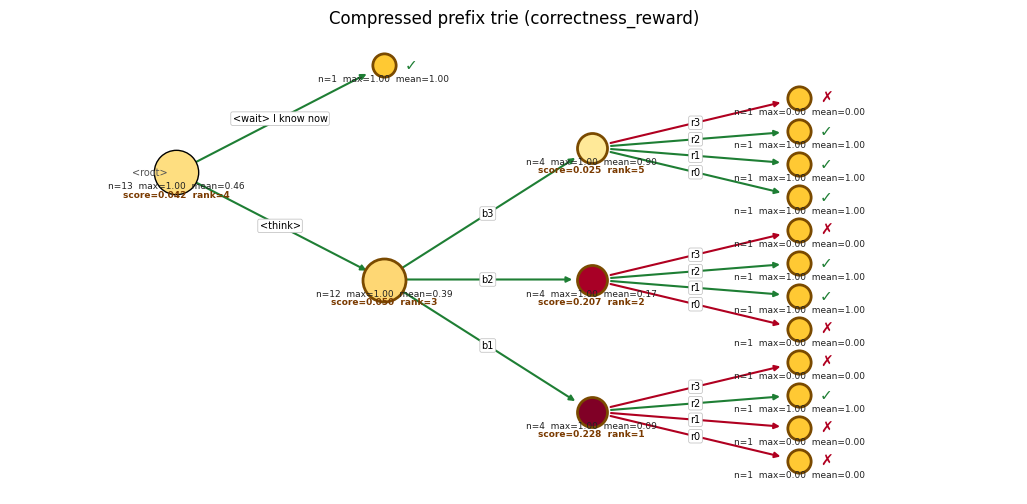

In [5]:
# =====================================================
# Requirement 2: trie viz with prefix "score" and "rank"
# =====================================================
# Single-child chains collapse onto edges. Node size = pass-through count, edge
# colour = reachable success (green / red), and below each node sits its count,
# running max/mean reward, plus the under-explored prefix `score` and `rank`
# (1 = most worth exploring). Node shade tracks score (darker = higher).
import matplotlib.pyplot as plt
from src.tree_vis import visualize_trie

key = "correctness_reward"

def prefix_score(node):
    # Issue 1. score PREFIXES only -- a leaf is a complete rollout, not a prefix,
    # so it receives no ranking (return None opts it out of score/rank/shading).
    # Issue 2. we only care about "proportion of correct rollouts", but less on "under-explorability" (smaller count)
    # achievable (best>0) x rarity-of-success (1 - EMA mean) / exploration (count)
    if not node.children:
        return None
    return node.best_reward(key) * (1.0 - node.reward_mean(key)) / node.count

ax = visualize_trie(prompt_trie, reward_key=key, figsize=(13, 6),
                    score_fn=prefix_score)
plt.show()

In [6]:
# =============================================
# Idea 3. Buffered Healthy Rollout Construction
# =============================================
# A per-query PrefixTrie buffers every distinct rollout (one leaf = one rollout).
# To repair a "degenerate" GRPO group (all-correct or all-wrong -> zero variance),
# we top it up with a buffered rollout of the missing kind. Sample from the SET
# of leaves (ignore visit count `n`): a rare rollout is as likely as a common one.
import random
rng = random.Random(0)
key = "correctness_reward"

# Inspect the buffer: distinct rollouts split by terminal correctness.
correct = [lf.prefix() for lf in prompt_trie.leaves() if lf.best_reward(key) > 0]
wrong   = [lf.prefix() for lf in prompt_trie.leaves() if lf.best_reward(key) == 0]
print(f"buffer: {len(correct)} correct / {len(wrong)} wrong distinct rollouts")

# Sample one of each kind (token sequences, root -> leaf).
print("sample correct:", prompt_trie.sample_rollout(correct=True,  key=key, rng=rng))
print("sample wrong:  ", prompt_trie.sample_rollout(correct=False, key=key, rng=rng))

def construct_healthy_group(trie, group, key="correctness_reward", rng=None):
    """If `group` (list of (tokens, is_correct)) is all-correct or all-wrong,
    append one buffered rollout of the missing kind so the group has variance.
    Returns the (possibly extended) group; unchanged if the buffer can't help."""
    n_correct = sum(c for _, c in group)
    if n_correct == 0:                       # all wrong -> need a correct one
        extra = trie.sample_rollout(correct=True, key=key, rng=rng)
        if extra is not None:
            group = group + [(extra, True)]
    elif n_correct == len(group):            # all correct -> need a wrong one
        extra = trie.sample_rollout(correct=False, key=key, rng=rng)
        if extra is not None:
            group = group + [(extra, False)]
    return group

# Demo: an all-wrong group gets a buffered correct rollout appended.
degenerate = [(["<think>", "b1", "r0"], False), (["<think>", "b1", "r1"], False)]
healthy = construct_healthy_group(prompt_trie, degenerate, key=key, rng=rng)
print(f"\nall-wrong group {len(degenerate)} -> healthy {len(healthy)}; "
      f"added correct: {healthy[-1][0]}")

buffer: 7 correct / 6 wrong distinct rollouts
sample correct: ['<think>', 'b1', 'r2']
sample wrong:   ['<think>', 'b1', 'r3']

all-wrong group 2 -> healthy 3; added correct: ['<think>', 'b1', 'r2']


In [7]:
# ==========================================================================
# How the mechanisms compose in ONE TreeTrainer generation step
# ==========================================================================
# DEFAULT = vanilla GRPO: advantages are the LOCAL group z-score, the trie is
# not consulted for any reward/advantage computation. Each trick is opt-in,
# and they compose by ORDERING inside _generate_and_score_completions:
#
#   (TRL rollout + local GRPO z-score advantages)
#   _update_global_tree            -> ingest this batch's REAL rollouts (only
#       runs if some enabled consumer needs the buffer)
#   [inject_rollout]   _inject_buffer_rollouts      -> swap ONE slot of a
#       degenerate group for a buffered rollout (leaf-recorded reward),
#       advantages recomputed as the LOCAL group z-score
#   [resample_prefix]  _resample_all_correct_groups -> REPLACE an all-correct
#       group with continuations of an under-explored prefix, re-scored,
#       advantages = LOCAL group z-score; prefix attended but gradient-free
#       via tool_mask (unless resample_train_prefix)
#   [buffered_baseline] _buffered_advantages        -> ONLY when explicitly
#       enabled: rescale by buffered std, re-centered to zero-sum per group
#   ...then in _compute_loss: [use_global_tree] trie.walk -> per-token OPA credit.
#
# Below: the DEFAULT advantage path (local z-score) on a toy batch, plus the
# trie acting in its default role — a passive record.
import numpy as np, random, torch
from src.tree_trainer import TreeTrainer, PrefixTrie

rng, key, eps = random.Random(0), "correctness_reward", 1e-8
stub = TreeTrainer.__new__(TreeTrainer)        # call the pure methods w/o trl/model
stub.num_generations = 4
trie = prompt_trie                              # the persistent per-prompt buffer

# Incoming batch: 4 rollouts for this prompt with raw correctness rewards.
batch = [(["<think>", "b4", "r0"], 0.0),
         (["<think>", "b4", "r1"], 0.0),
         (["<think>", "b4", "r2"], 1.0),
         (["<think>", "b4", "r3"], 0.0)]
corr = np.array([c for _, c in batch])
c_t, f_t, t_t = torch.tensor(corr), torch.zeros(len(corr)), torch.tensor(corr)

# Group label (pure observation — decides which repair trick MAY act).
print("group label:", stub._classify_group(c_t, f_t, t_t))

# DEFAULT advantage: local group z-score. No trie involved.
adv = (corr - corr.mean()) / (corr.std() + eps)
print("local z-score adv:", np.round(adv, 2), f"(sum {adv.sum():.0e})")

# Ingest the batch into the persistent trie (passive record, once per step).
for toks, c in batch:
    trie.insert(toks, adv=c, rewards={key: c}, reward_ema=0.9)
print(f"trie record: {trie.count} root pass-throughs, "
      f"{len(list(trie.leaves()))} distinct rollouts")

# What the OPT-IN consumers would read from that record:
print("[use_global_tree]  per-token OPA credit:",
      np.round(trie.walk(["<think>", "b4", "r2"], mode="max"), 2))
print("[resample_prefix]  under-explored prefix:",
      trie.sample_prefix(key=key, rng=rng))

Idea 2  group label: mixed
Idea 3  buffered baseline m=0.455 s=0.498
        in-batch adv : [-0.58 -0.58  1.73 -0.58]
        buffered adv : [-0.91 -0.91  1.09 -0.91]
Idea 1  trie now: 17 root pass-throughs, 17 distinct rollouts
        OPA per-token credit for the correct rollout: [1. 1. 1.]
Idea 4  next generation forced from buffered prefix: ['<think>', 'b4']


In [8]:
# =========================================================
# Idea 1 (persistence). Save / load the global trie across runs
# =========================================================
# TreeTrainer keeps one trie per prompt in self._global_tries[pkey] and persists
# the whole dict to JSON via save_tries / load_tries, so a resumed run keeps its
# buffer. Serialization goes through PrefixTrie.to_dict / from_dict: parent/token
# back-links and +/-inf extrema are dropped on save and rebuilt on load.
import json
from src.tree_trainer import PrefixTrie

# Mirror the trainer's store: key = prompt token-id tuple -> PrefixTrie.
global_tries = {(101, 102): prompt_trie}

blob = json.dumps({"tries": [[list(pk), t.to_dict()] for pk, t in global_tries.items()]})
restored = {tuple(pk): PrefixTrie.from_dict(d) for pk, d in json.loads(blob)["tries"]}

orig, back = prompt_trie, restored[(101, 102)]
print(f"round-trip  count {orig.count}->{back.count}  "
      f"mean {orig.reward_mean(key):.3f}->{back.reward_mean(key):.3f}  "
      f"std {orig.reward_std(key):.3f}->{back.reward_std(key):.3f}")
node = back.get_node(["<think>", "b1"])         # back-links + children rebuilt
print("rebuilt prefix:", node.prefix(),
      "| distinct rollouts:", len(list(back.leaves())))

round-trip  count 17->17  mean 0.389->0.389  std 0.487->0.487
rebuilt prefix: ['<think>', 'b1'] | distinct rollouts: 17


In [1]:
# ===========================================================================
# Test kernel 0: stub harness — drive the REAL trainer methods without a model
# ===========================================================================
# TreeTrainer.__new__ gives an instance whose methods run as-is; we fake only
# the attributes they touch (tokenizer, reward funcs, accelerator). Tokens are
# ints; decode = space-joined ints; correctness = gold token appears in text.
# Trick flags are AUTO-COPIED from TreeTrainer.__init__'s signature defaults
# (all off), so new flags propagate to the stub without manual edits; override
# per kernel via make_stub(flag=True).
import torch, random, inspect
from types import SimpleNamespace
from src.tree_trainer import TreeTrainer, PrefixTrie, _TOTAL_KEY

class FakeTok:
    pad_token_id = 0
    eos_token_id = 0
    def decode(self, ids, skip_special_tokens=False):
        return " ".join(str(int(t)) for t in ids if int(t) != 0)

def correctness_reward(prompts, completions, gold_answer, **kw):
    return [1.0 if g in c.split() else 0.0 for c, g in zip(completions, gold_answer)]

def format_reward(prompts, completions, **kw):
    return [0.1] * len(completions)

def make_stub(g=4, **flags):
    t = TreeTrainer.__new__(TreeTrainer)
    # every keyword of TreeTrainer.__init__ with a simple default becomes an
    # attribute (e.g. buffered_baseline, inject_rollout, resample_inject, ...)
    for name, p in inspect.signature(TreeTrainer.__init__).parameters.items():
        if p.default is not inspect.Parameter.empty:
            setattr(t, name, flags.pop(name, p.default))
    assert not flags, f"unknown flags: {list(flags)}"
    t.processing_class = FakeTok()
    t.num_generations, t.num_iterations = g, 1
    t.reward_funcs = [correctness_reward, format_reward]
    t.reward_func_names = ["correctness_reward", "format_reward"]
    t._opa_reward_keys = ("correctness_reward", "format_reward")
    t._global_tries = {}
    t.model = SimpleNamespace(training=True)
    t.state = None
    t.accelerator = SimpleNamespace(device="cpu", gather=lambda x: x, process_index=0)
    return t

def make_batch(prompt, completions, local):
    """out-dict shaped like TRL's generation batch for ONE group."""
    g = len(completions)
    width = max(len(c) for c in completions)
    cids = torch.zeros(g, width, dtype=torch.long)
    for i, c in enumerate(completions):
        cids[i, :len(c)] = torch.tensor(c)
    cmask = (cids != 0).long()
    r = local.sum(1)
    adv = (r - r.mean()) / (r.std() + 1e-4)            # vanilla in-batch GRPO
    out = {"advantages": adv, "completion_ids": cids, "completion_mask": cmask,
           "prompt_ids": torch.tensor([prompt] * g),
           "prompt_mask": torch.ones(g, len(prompt), dtype=torch.long),
           "correctness_reward": local[:, 0].clone(),
           "format_reward": local[:, 1].clone()}
    return out, [tuple(prompt)] * g

print("harness ready; stub flags:",
      [n for n, p in inspect.signature(TreeTrainer.__init__).parameters.items()
       if p.default is not inspect.Parameter.empty][:14], "...")


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

objc[55403]: Class AVFFrameReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2f0584798) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x309f4c3a8). One of the two will be used. Which one is undefined.
objc[55403]: Class AVFAudioReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2f05847e8) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x309f4c3f8). One of the two will be used. Which one is undefined.


harness ready; stub flags: ['use_global_tree', 'credit_mode', 'shaped_reward', 'shaped_kwargs', 'difficulty_map', 'virtual_rollout', 'virtual_max_reward', 'record_reward_keys', 'tree_persist_path', 'buffered_baseline', 'buffered_eps', 'inject_rollout', 'inject_incorrect', 'resample_prefix'] ...


In [2]:
# ===========================================================================
# Test kernel 1: _update_global_tree (buffer ingestion ONLY)
# ===========================================================================
# The trie is a passive record here: ingestion happens once per generation,
# BEFORE any repair hook needs it. Advantages are NOT touched — they remain
# TRL's local group z-score (buffered_baseline stays off).
stub = make_stub()
prompt = [5, 6]                                       # gold answer token: "9"
mixed = [[7, 8], [7, 9], [9, 8], [8, 8]]              # 2 correct, 2 wrong
local = torch.tensor([[0., .1], [1., .1], [1., .1], [0., .1]])
out, pkeys = make_batch(prompt, mixed, local)
adv_before = out["advantages"].clone()

stub._update_global_tree(out, local, pkeys)           # step-0 ingest
trie = stub._global_tries[tuple(prompt)]
assert trie.count == 4, "4 rollouts should be ingested"
assert len(list(trie.leaves())) == 4, "4 distinct rollouts"
assert torch.equal(out["advantages"], adv_before), "ingestion must NOT touch advantages"

leaf = trie.get_node([7, 9])                          # per-rollout record
print(f"trie: count={trie.count}, leaves={len(list(trie.leaves()))}")
print(f"leaf [7,9]: correctness={leaf.best_reward('correctness_reward'):.1f}, "
      f"total={leaf.best_reward(_TOTAL_KEY):.1f}")
print("advantages untouched (local z-score):", out["advantages"].round(decimals=2).tolist())

trie: count=4, leaves=4
leaf [7,9]: correctness=1.0, total=1.1
advantages untouched (local z-score): [-0.8700000047683716, 0.8700000047683716, 0.8700000047683716, -0.8700000047683716]


In [3]:
# ===========================================================================
# Test kernel 2: _inject_buffer_rollouts (repair degenerate group) — STANDALONE
# ===========================================================================
# Tricks don't overlap: with buffered_baseline=False (Idea 1 off) the trie is
# used ONLY to fetch the injected rollout + its recorded reward; the group's
# advantages are recomputed with the LOCAL group mean/std over the substituted
# rewards. The injected reward is the one RECORDED at the rollout's leaf node
# (not the buffer-wide best, which may belong to a different rollout).
stub2 = make_stub(buffered_baseline=False, inject_rollout=True)
out0, pkeys0 = make_batch(prompt, mixed, local)       # seed buffer w/ mixed batch
stub2._update_global_tree(out0, local, pkeys0)
trie2 = stub2._global_tries[tuple(prompt)]

all_wrong = [[8, 8], [7, 8], [8, 7], [7, 7]]          # no "9" anywhere
local_aw = torch.tensor([[0., .1]] * 4)
out_aw, pk_aw = make_batch(prompt, all_wrong, local_aw)
before = out_aw["completion_ids"].clone()

random.seed(0)
stub2._inject_buffer_rollouts(out_aw, local_aw, pk_aw)
changed = (out_aw["completion_ids"] != before).any(dim=1).nonzero().flatten().tolist()
assert len(changed) == 1, f"expected exactly one swapped slot, got {changed}"
slot = changed[0]
toks = out_aw["completion_ids"][slot][out_aw["completion_mask"][slot].bool()].tolist()
assert "9" in stub2.processing_class.decode(toks).split(), "injected rollout not correct-kind"

# LOCAL group recompute with the LEAF-recorded reward of the sampled rollout:
r = local_aw.sum(1)
r[slot] = trie2.get_node(toks).best_reward(_TOTAL_KEY)
expect = (r - r.mean()) / (r.std() + stub2.buffered_eps)
assert torch.allclose(out_aw["advantages"], expect.to(out_aw["advantages"])), "group recompute mismatch"
print(f"slot {slot} swapped -> buffered correct rollout {toks} (leaf reward {r[slot]:.1f})")
print(f"LOCAL group z-score -> {out_aw['advantages'].round(decimals=2).tolist()}")

slot 3 swapped -> buffered correct rollout [7, 9] (leaf reward 1.1)
LOCAL group z-score -> [-0.5, -0.5, -0.5, 1.5]


In [ ]:
# ===========================================================================
# Test kernel 2b: inject_incorrect — buffered WRONG rollout breaks all-correct
# ===========================================================================
# Mirror of kernel 2: an ALL-CORRECT group (zero variance, nothing to learn)
# gets ONE slot swapped for a buffered WRONG rollout, carrying its
# leaf-recorded reward (e.g. format-only 0.1, NOT a hardcoded 0). Group
# advantages = LOCAL z-score over the substituted rewards: the wrong rollout
# gets the negative signal, the g-1 correct ones get (small) positive.
stub2b = make_stub(inject_rollout=True, inject_incorrect=True)
out0, pkeys0 = make_batch(prompt, mixed, local)       # seed buffer w/ mixed batch
stub2b._update_global_tree(out0, local, pkeys0)
trie2b = stub2b._global_tries[tuple(prompt)]
# buffer's wrong rollouts: [7,8] and [8,8] (leaf total 0.1 = format only)

all_correct = [[7, 9], [9, 8], [9, 9], [6, 9]]        # every row carries "9"
local_ac = torch.tensor([[1., .1]] * 4)
out_ac2, pk_ac2 = make_batch(prompt, all_correct, local_ac)
before = out_ac2["completion_ids"].clone()

random.seed(0)
stub2b._inject_buffer_rollouts(out_ac2, local_ac, pk_ac2)
changed = (out_ac2["completion_ids"] != before).any(dim=1).nonzero().flatten().tolist()
assert len(changed) == 1, f"expected exactly one swapped slot, got {changed}"
slot = changed[0]
toks = out_ac2["completion_ids"][slot][out_ac2["completion_mask"][slot].bool()].tolist()
assert "9" not in stub2b.processing_class.decode(toks).split(), "injected rollout must be WRONG"

# Leaf-recorded reward + LOCAL group z-score over substituted rewards.
r = local_ac.sum(1)
r[slot] = trie2b.get_node(toks).best_reward(_TOTAL_KEY)
expect = (r - r.mean()) / (r.std() + stub2b.buffered_eps)
assert torch.allclose(out_ac2["advantages"], expect.to(out_ac2["advantages"]))
assert out_ac2["advantages"][slot] < 0 < out_ac2["advantages"][(slot + 1) % 4], \
    "wrong rollout negative, correct rollouts positive"
print(f"slot {slot} swapped -> buffered WRONG rollout {toks} (leaf reward {r[slot]:.1f})")
print(f"LOCAL group z-score -> {out_ac2['advantages'].round(decimals=2).tolist()}")

In [4]:
# ===========================================================================
# Test kernel 3: _resample_all_correct_groups — STANDALONE
# ===========================================================================
# An all-correct group is REPLACED in the same step: generation is stubbed by
# monkeypatching GRPOTrainer._generate_single_turn (what `super()` resolves
# to). The trie's only role is providing the under-explored prefix; advantages
# are the LOCAL group z-score over the re-scored rewards — no global buffer.
# fake_gen returns a MIXED forced group ([42,9] correct / [42,8] wrong); if it
# came back uniform the z-score would correctly be 0s (variance not restored).
import trl

stub3 = make_stub(resample_prefix=True, resample_train_prefix=False)
out0, pkeys0 = make_batch(prompt, mixed, local)       # seed buffer (mixed batch)
stub3._update_global_tree(out0, local, pkeys0)
trie3 = stub3._global_tries[tuple(prompt)]
print("buffered prefix candidate:", trie3.sample_prefix(rng=random.Random(0)))

all_correct = [[7, 9, 9, 9], [9, 8, 8, 9], [9, 9, 9, 9], [6, 9, 9, 9]]  # all carry "9"
local_ac = torch.tensor([[1., .1]] * 4)
out_ac, pk_ac = make_batch(prompt, all_correct, local_ac)
inputs = [{"prompt": "5 6", "gold_answer": "9"}] * 4

def fake_gen(self, texts):                            # mixed canned continuations
    return None, [[42, 9] if i % 2 == 0 else [42, 8] for i in range(len(texts))], None, None

orig = trl.GRPOTrainer._generate_single_turn
trl.GRPOTrainer._generate_single_turn = fake_gen
try:
    random.seed(0)
    stub3._resample_all_correct_groups(out_ac, inputs, local_ac, pk_ac)
finally:
    trl.GRPOTrainer._generate_single_turn = orig

cids, tmask = out_ac["completion_ids"], out_ac["tool_mask"]
row0 = cids[0][out_ac["completion_mask"][0].bool()].tolist()
plen = len(row0) - 2                                  # prefix + continuation
assert row0[-2:] == [42, 9], "continuation tokens not spliced"
assert (tmask[:, :plen] == 0).all() and (tmask[0, plen:len(row0)] == 1).all(), \
    "tool_mask must be 0 on prefix, 1 on continuation"
r_new = local_ac.sum(1)                               # rewards rewritten by resample
assert torch.allclose(r_new, torch.tensor([1.1, 0.1, 1.1, 0.1])), "local not re-scored"
expect = (r_new - r_new.mean()) / (r_new.std() + stub3.buffered_eps)
assert torch.allclose(out_ac["advantages"], expect.to(out_ac["advantages"])), \
    "advantages must be the LOCAL group z-score over re-scored rewards"
assert abs(out_ac["advantages"].sum().item()) < 1e-5, "zero-sum per group"
print(f"group replaced: e.g. row0 {row0}, tool_mask row0 {tmask[0].tolist()}")
print(f"local z-score adv -> {out_ac['advantages'].round(decimals=2).tolist()} (zero-sum)")

buffered prefix candidate: [7]
group replaced: e.g. row0 [7, 42, 9], tool_mask row0 [0, 1, 1, 1]
local z-score adv -> [0.8700000047683716, -0.8700000047683716, 0.8700000047683716, -0.8700000047683716] (zero-sum)


In [5]:
# ===========================================================================
# Test kernel 3b: resample_inject — guaranteed contrast THROUGH the prefix
# ===========================================================================
# Worst case for plain resample: ALL g forced continuations come back WRONG
# (fake_gen -> [42, 8] for everyone) -> zero variance again, adv = 0s.
# With resample_inject=True, ONE random slot is a buffered CORRECT rollout
# sampled from the PREFIX NODE's subtree (it must exist: sample_prefix only
# picks prefixes with best_reward > 0) -> the group contrasts "the success
# through this prefix" vs g-1 fresh failures from the same prefix.
# The injected row is a full rollout: fully trained (tool_mask stays 1s).
import trl

stub4 = make_stub(resample_prefix=True, resample_inject=True)
out0, pkeys0 = make_batch(prompt, mixed, local)       # seed buffer (mixed batch)
stub4._update_global_tree(out0, local, pkeys0)
# buffer's correct rollouts: [7,9] (through prefix [7]) and [9,8] (not)

all_correct = [[7, 9, 9, 9], [9, 8, 8, 9], [9, 9, 9, 9], [6, 9, 9, 9]]
local_ac = torch.tensor([[1., .1]] * 4)
out_ac, pk_ac = make_batch(prompt, all_correct, local_ac)
inputs = [{"prompt": "5 6", "gold_answer": "9"}] * 4

def fake_gen(self, texts):                            # every continuation WRONG
    return None, [[42, 8] for _ in texts], None, None

orig = trl.GRPOTrainer._generate_single_turn
trl.GRPOTrainer._generate_single_turn = fake_gen
try:
    random.seed(0)
    stub4._resample_all_correct_groups(out_ac, inputs, local_ac, pk_ac)
finally:
    trl.GRPOTrainer._generate_single_turn = orig

corr = out_ac["correctness_reward"]
assert corr.sum() == 1.0, "exactly one slot should be the buffered correct rollout"
j = int(corr.argmax())
toks = out_ac["completion_ids"][j][out_ac["completion_mask"][j].bool()].tolist()
assert toks == [7, 9], "injected rollout must pass THROUGH the sampled prefix [7]"
assert out_ac["tool_mask"][j].sum() == out_ac["tool_mask"].shape[1], \
    "injected full rollout must be fully trained (no prefix zeros)"
assert (out_ac["tool_mask"][(j + 1) % 4][0] == 0), "forced rows keep prefix zeros"
r_new = local_ac.sum(1)
expect = (r_new - r_new.mean()) / (r_new.std() + stub4.buffered_eps)
assert torch.allclose(out_ac["advantages"], expect.to(out_ac["advantages"]))
print(f"slot {j} = correct rollout through prefix [7]: {toks}, fully trained")
print(f"adv (would be 0s without inject) -> {out_ac['advantages'].round(decimals=2).tolist()}")

slot 0 = correct rollout through prefix [7]: [7, 9], fully trained
adv (would be 0s without inject) -> [1.5, -0.5, -0.5, -0.5]


In [ ]:
# Buffer tricks
# 1. Global buffer based advantage computation
# 2. Inject buffered 'correct' rollout to break degeneracy (hack only & reward hacking) group
# 2.1. Inject buffered 'wrong' rollout to break all-correct group
# 3. Resample from rare prefix to break all-correct group (train on prefix)
# 3.1. Resample from rare prefix to break all-correct group (no train on prefix)

# Predictive velocity 
# Mainly test with it replacing correctness reward
# v1. use model's own answer a for computing p(a | o) | requires model to search out correct answer to starts working
# v2. use GT answer a* for computing p(a* | o)
# test out v2 on llama models (clearest signal since llama can't solve game of 24)


# Lottery ensemble 
# Phase A: lottery — grow the shared buffer
# for S in 0 1 2 3; do
#   python script/tripo_game24.py --seed $S --max-steps 10 \
#     --tree-persist-path out/trie.json --eval-steps 0 ...
# done
# # Phase B: main run — absorb then on-policy
# python script/tripo_game24.py --seed 0 --max-steps 200 \
#   --tree-persist-path out/trie.json --absorb-steps 10 --absorb-groups-per-query 2 ...


tensor([[ 7, 42,  9,  0],
        [ 7, 42,  8,  0],
        [ 7, 42,  9,  0],
        [ 7, 42,  8,  0]])

In [ ]:
# (Done). validate the prefix rollout gadgets

# (TBD). fix the server mode arguments and prep a script for it
# (TBD). run experiments on the buffer ideas 
# (TBD). figure out the tricks for running GRPO on Terminal Bench v2